# 01 ? Data Exploration
Esplorazione del dataset grezzo: struttura, statistiche descrittive, visualizzazione segnali.

In questa fase non sto ancora costruendo il modello, ma verifico che il materiale in ingresso sia coerente con il contesto clinico della riabilitazione cardiaca. Capire come sono distribuiti pazienti, test e segnali ? fondamentale perch? eventuali sbilanciamenti o anomalie possono propagarsi in tutte le fasi successive.

L'obiettivo metodologico ? duplice: da un lato descrivere il dataset in modo trasparente, dall'altro capire se ECG e accelerometro catturano informazioni plausibili rispetto allo sforzo fisico e allo stato funzionale del paziente.


In [1]:
# Porto la root del progetto nel path per riutilizzare le funzioni sviluppate nella tesi senza duplicare codice.
import sys; sys.path.insert(0, '..')
# Disattivo i warning per mantenere l'output del notebook leggibile e concentrarmi sull'interpretazione.
import warnings; warnings.filterwarnings('ignore')
# NumPy e pandas servono per i controlli numerici e tabellari dell'esplorazione iniziale.
import numpy as np, pandas as pd
# Le librerie di plotting mi aiutano a collegare subito i numeri a un'interpretazione fisiologica.
import matplotlib.pyplot as plt, seaborn as sns
# Uso i loader del progetto per leggere i dati sempre con la stessa logica della pipeline finale.
from src.data_loader import list_patients, load_patient, load_subject_info, load_test_availability, get_test_segments
from src.visualization import plot_ecg_acc_overview, plot_rr_timeseries
# Uno stile grafico uniforme rende pi? facile confrontare soggetti e prove diverse.
sns.set_theme(style='whitegrid')
# In notebook voglio le figure inline per commentarle immediatamente nel flusso dell'analisi.
%matplotlib inline


## 1. Pazienti disponibili

Parto dal numero di pazienti per capire la dimensione reale del campione e la sua variabilit? inter-soggetto. In ambito cardiologico questo passaggio ? importante perch? l'eterogeneit? clinica pu? essere elevata e condizionare sia le statistiche descrittive sia la generalizzazione del modello.


In [2]:
# Recupero l'elenco dei pazienti per verificare subito la numerosit? del dataset reale.
patients = list_patients()
# Stampare il conteggio mi permette di capire quanto il campione sia compatibile con un'analisi esplorativa robusta.
print(f'Pazienti totali: {len(patients)}')
# Visualizzo anche gli identificativi per controllare se la codifica ? ordinata e priva di buchi sospetti.
print(patients)


Pazienti totali: 80
['001', '012', '020', '026', '036', '040', '046', '048', '050', '052', '058', '059', '061', '065', '068', '073', '078', '082', '102', '108', '110', '111', '115', '123', '132', '137', '139', '144', '146', '150', '151', '155', '159', '163', '177', '185', '187', '188', '197', '198', '201', '203', '208', '212', '216', '223', '224', '234', '236', '237', '238', '239', '240', '247', '249', '250', '251', '254', '255', '257', '261', '268', '269', '271', '276', '281', '282', '288', '295', '296', '297', '302', '307', '311', '316', '317', '318', '319', '324', '337']


## 2. Informazioni cliniche

Le variabili cliniche aggiungono contesto ai segnali fisiologici: et?, BMI e classe NYHA aiutano a interpretare differenze di frequenza cardiaca, tolleranza allo sforzo e pattern di movimento. Prima di estrarre feature conviene quindi verificare che questi metadati siano disponibili e con distribuzioni plausibili.


In [3]:
# Carico la tabella clinica per collegare i segnali alla condizione del paziente.
subject_info = load_subject_info()
# La shape mi dice subito quante osservazioni e quante variabili cliniche ho a disposizione.
print('Shape:', subject_info.shape)
# Un'anteprima iniziale serve a controllare formato, indici e possibili valori mancanti evidenti.
subject_info.head()


Shape: (80, 43)


,"General information|Age, years","Unnamed: 2_level_0|Gender (0 - male, 1 - female)","Unnamed: 3_level_0|Height, cm","Unnamed: 4_level_0|Weight, kg",Unnamed: 5_level_0|EFS score,Surgery information|Days after surgery,"Unnamed: 7_level_0|Surgery type (0 - coronary artery bypass graft, 1 - isolated valve, 2 - combined)",Comorbidities|Heart failure based on NYHA class,"Unnamed: 9_level_0|Atrial fibrillation (0 - no AF, 1 - permanent, 2 - persistent, 3 - paroxysmal)",Unnamed: 10_level_0|Chronic obstructive pulmonary disease,...,"Unnamed: 34_level_0|Cadence, steps/min","Unnamed: 35_level_0|Velocity, km/h","Gait analysis: balance parameters (mean±std)|Length of gait line (left), mm","Unnamed: 37_level_0|Length of gait line (right), mm","Unnamed: 38_level_0|Single limb support line (left), mm","Unnamed: 39_level_0|Single limb support line (right), mm","Unnamed: 40_level_0|Ant/post position, mm","Unnamed: 41_level_0|Lateral symmetry, mm","Unnamed: 42_level_0|Max gait line velocity, cm/s",BMI
patient_id,,,,,,,,,,,,,,,,,,,,,
001,77,0,170,76,6,21,2,II,0,0,...,96±4,0.8±0.1,150.5±22.5,134.1±19.8,21.6±6.9,18.8±7.4,11.0±11.1,11.5±47.5,578,26.297578
012,69,0,177,110,6,20,2,III,3,1,...,73±3,1.1±0.1,129.6±11.2,147.8±6.0,26.3±7.6,31.7±10.5,11.0±7.5,-11.9±38.4,109.9,35.111239
020,74,0,183,95,7,13,0,II,0,0,...,91±3,1.8±1,65.8±20.3,136.4±17.9,24.8±8.4,38.3±15.2,25.0±8.3,-23.4±34.8,457.9,28.367524
026,70,1,150,72,6,14,0,II,0,0,...,96±3,1.5±0.1,131.1±6.9,129.1±7.9,19.1±9.2,20.0±9.2,3.7±6.9,-3.7±24.6,128.7,32.000000
036,70,0,178,92,7,21,0,III,0,0,...,69±2,0.6±0.1,169.5±30.5,143.5±21.1,14.8±7.1,20.4±9.6,27.7±11.1,-10.4±35.8,379.7,29.036738


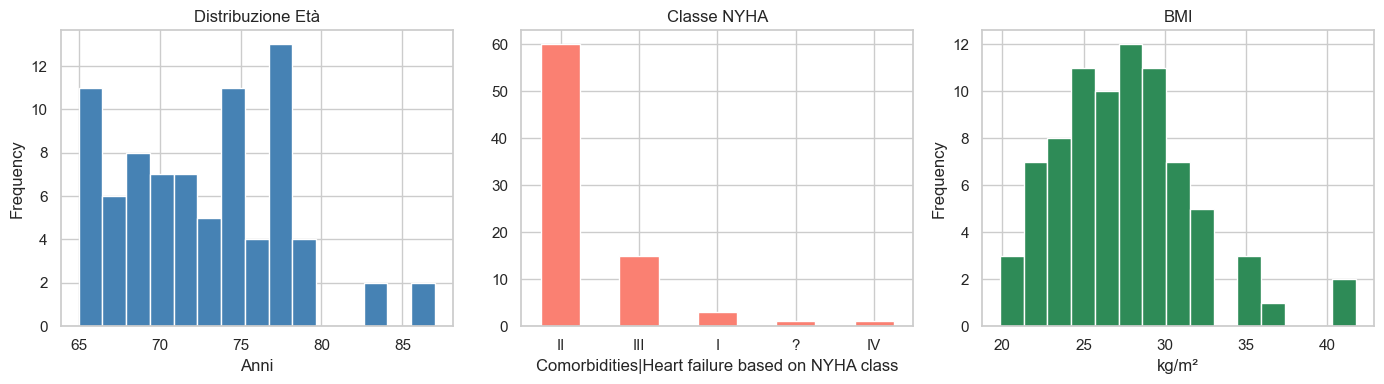

In [4]:
# Confronto in un'unica figura tre variabili clinicamente rilevanti per avere una vista sintetica del campione.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# Cerco dinamicamente la colonna et? per rendere il notebook robusto a piccole differenze di naming.
age_col = next(c for c in subject_info.columns if 'Age' in c)
# L'istogramma dell'et? aiuta a capire se il dataset riflette una popolazione tipica della riabilitazione cardiaca.
subject_info[age_col].astype(float).plot.hist(bins=15, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuzione Et?'); axes[0].set_xlabel('Anni')

# La classe NYHA ? una sintesi della limitazione funzionale e pu? spiegare differenze nei pattern cardiaci e motori.
nyha_col = next((c for c in subject_info.columns if 'NYHA' in c), None)
if nyha_col:
    subject_info[nyha_col].value_counts().plot.bar(ax=axes[1], color='salmon', edgecolor='white')
    axes[1].set_title('Classe NYHA'); axes[1].tick_params(axis='x', rotation=0)

# Il BMI ? utile perch? pu? influenzare il carico meccanico del movimento e la risposta allo sforzo.
if 'BMI' in subject_info.columns:
    subject_info['BMI'].astype(float).plot.hist(bins=15, ax=axes[2], color='seagreen', edgecolor='white')
    axes[2].set_title('BMI'); axes[2].set_xlabel('kg/m?')
# Compatto il layout per facilitare il confronto visivo tra indicatori clinici diversi.
plt.tight_layout(); plt.show()


## 3. Disponibilit? test

Non tutti i pazienti completano necessariamente tutte le prove riabilitative. Controllare la disponibilit? dei test ? essenziale perch? eventuali mancanze possono introdurre bias nelle feature estratte e nella successiva fase di apprendimento supervisionato.


In [5]:
# Verifico quali test sono effettivamente presenti per ogni soggetto prima di confrontare le varie condizioni.
test_avail = load_test_availability()
# La shape riassume il perimetro del dataset a livello di prove annotate.
print('Shape:', test_avail.shape)
# Conteggio i NaN per capire dove il protocollo sperimentale ? incompleto o non registrato.
missing = test_avail.isna().sum()
print('
Dati mancanti per test:')
print(missing)
# Mostro la tabella completa cos? posso individuare eventuali pattern sistematici di assenza.
test_avail


Shape: (80, 5)

Dati mancanti per test:
STAIR             6
6MWT             13
TUG               3
VELO              5
GAIT_ANALYSIS    12
dtype: int64


,STAIR,6MWT,TUG,VELO,GAIT_ANALYSIS
Patient ID,,,,,
001,001_1,001_1,001_1,001_1,001_1
012,012_2,012_1,012_1,012_3,NaN
020,NaN,NaN,020_1,020_2,020_1
026,NaN,026_1,026_1,026_1,NaN
036,036_1,036_1,036_1,036_1,NaN
...,...,...,...,...,...
317,317_1,317_1,317_1,317_1,317_1
318,318_1,NaN,NaN,NaN,318_1
319,319_1,319_1,319_1,319_1,319_1


## 4. Segnale grezzo ? paziente 001

Osservare un caso concreto aiuta a verificare se annotazioni e segnali sono allineati nel tempo. Sul singolo paziente ? pi? semplice riconoscere transizioni tra riposo e attivit?, artefatti da movimento e differenze di intensit? che poi le feature dovranno sintetizzare.


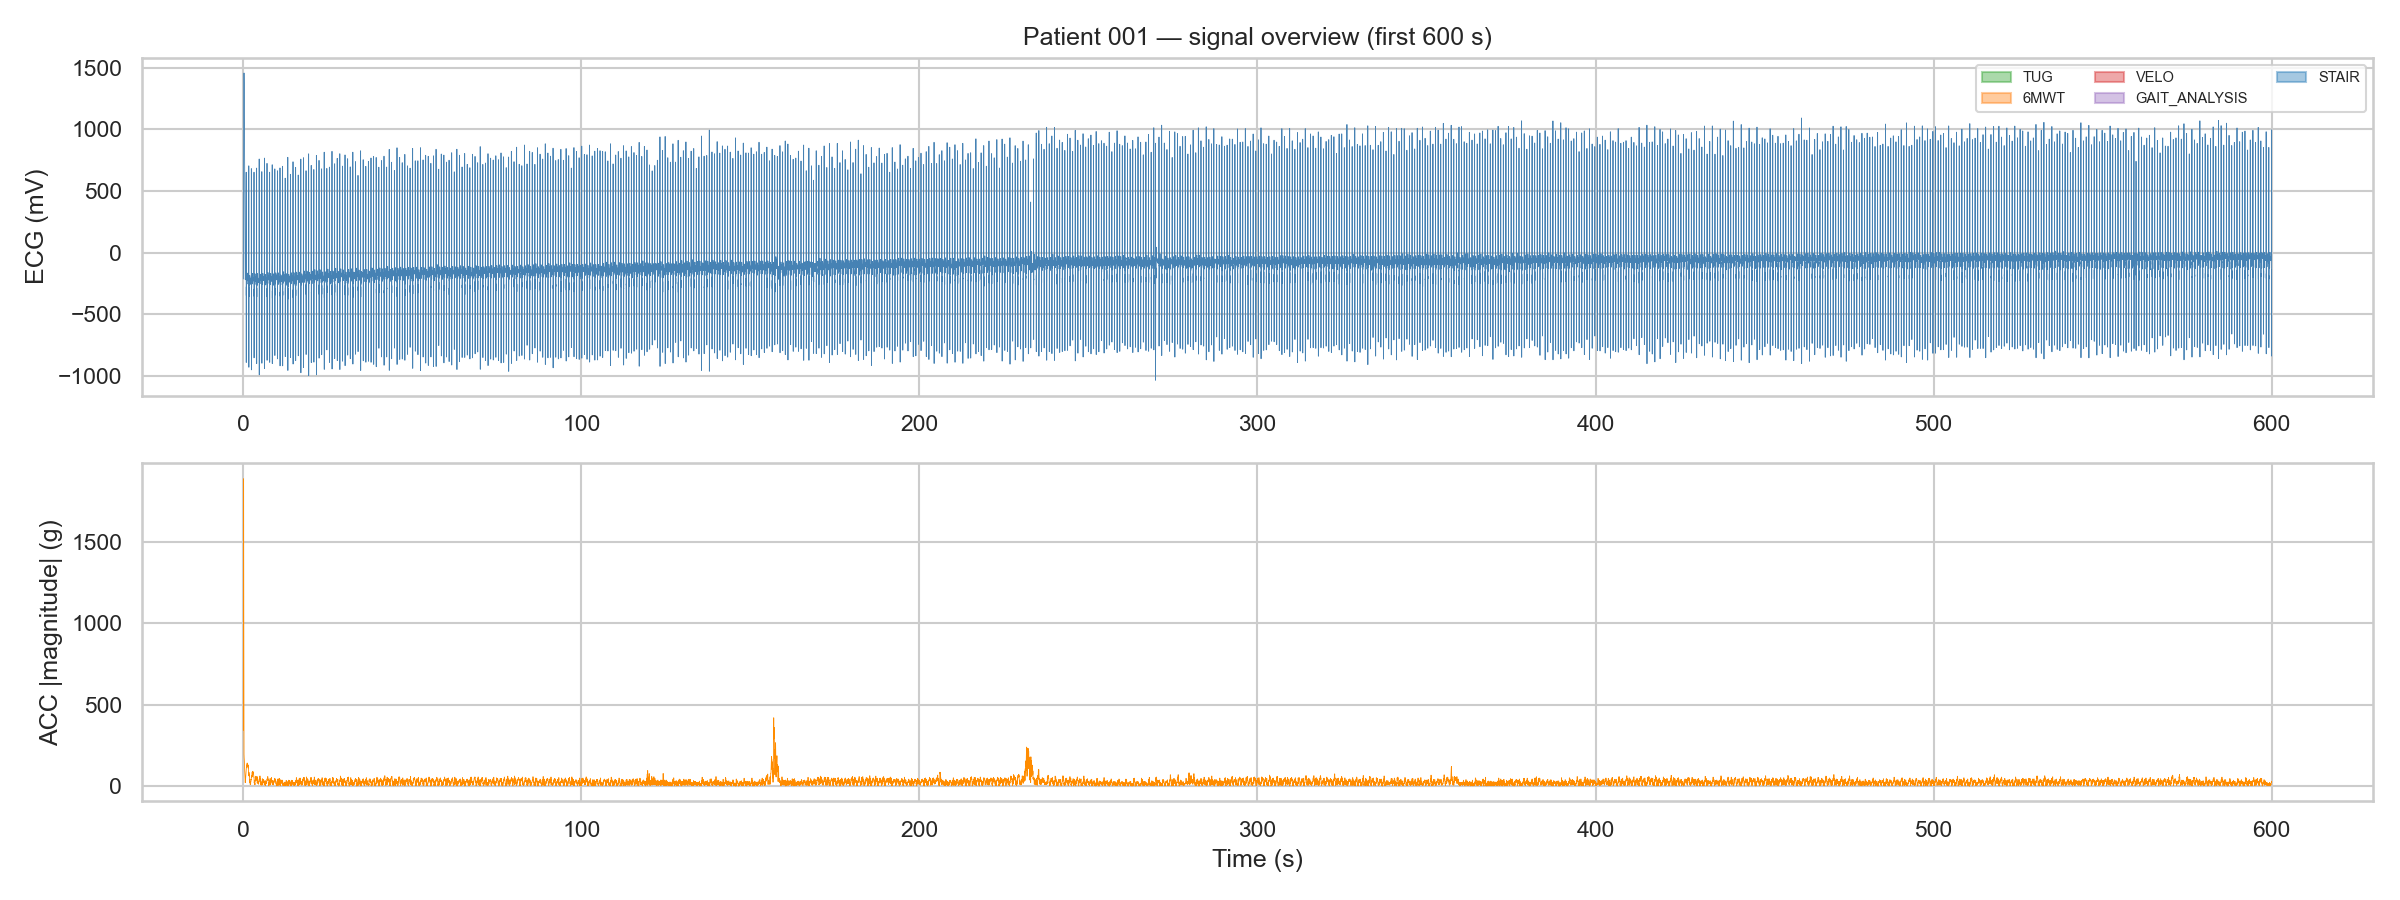

In [6]:
# Scelgo un paziente di esempio per collegare le statistiche aggregate a un tracciato reale.
data = load_patient('001', 1)
# Separo ECG e accelerometro perch? descrivono due aspetti complementari: risposta cardiaca e attivit? motoria.
ecg = data['ecg']; acc = data['acc']
# Ricostruisco i segmenti dei test per leggere il segnale alla luce delle diverse fasi del protocollo.
segments = get_test_segments(
    ecg['ann_samples'], ecg['ann_labels'],
    acc['ann_samples'], acc['ann_labels'],
    len(ecg['signal']), len(acc['signal_x']))
from src.preprocessing import preprocess_acc
# Preprocesso l'ACC prima del plot cos? la magnitudine ? pi? interpretabile del singolo asse grezzo.
acc_prep = preprocess_acc(acc['signal_x'], acc['signal_y'], acc['signal_z'], acc['fs'])
# La panoramica con segmenti annotati mi serve per vedere se il carico motorio cresce dove mi aspetto anche dal punto di vista clinico.
plot_ecg_acc_overview(ecg['signal'], acc_prep['magnitude'],
    ecg['fs'], acc['fs'], test_segments=segments,
    output_path='../results/figures/overview_001.png',
    patient_id='001', max_duration_s=600)
# Ricarico l'immagine salvata per avere una figura pulita e riutilizzabile anche nella stesura della tesi.
from IPython.display import Image; Image('../results/figures/overview_001.png')


## 5. Statistiche segnale

Chiudo l'esplorazione con alcune misure di base su durata, frequenza di campionamento e range dei segnali. Sono controlli semplici ma cruciali: se questi valori non fossero coerenti, qualunque preprocessing o estrazione di feature risulterebbe poco affidabile.


In [7]:
# Calcolo la lunghezza del segnale ECG per trasformarla in durata osservabile.
n_ecg = len(ecg['signal'])
# Faccio lo stesso per l'ACC, cos? posso verificare la coerenza temporale tra sensori diversi.
n_acc = len(acc['signal_x'])
# Durata e frequenza di campionamento sono il primo controllo di qualit? sulla registrazione fisiologica.
print(f"ECG ? durata: {n_ecg/ecg['fs']:.1f} s  |  fs={ecg['fs']} Hz")
print(f"ACC ? durata: {n_acc/acc['fs']:.1f} s  |  fs={acc['fs']} Hz")
# Il range dell'ECG aiuta a capire se ampiezze e artefatti sono compatibili con un tracciato realistico.
print(f"ECG range: {ecg['signal'].min():.3f} .. {ecg['signal'].max():.3f} mV")
# Il range dell'ACC suggerisce quanto movimento e quanta componente gravitazionale sono presenti nella registrazione.
print(f"ACC X range: {acc['signal_x'].min():.3f} .. {acc['signal_x'].max():.3f} g")
# Elenco i test annotati per confermare che i segmenti usati nei grafici corrispondano al protocollo previsto.
print(f"Test annotati: {list(segments.keys())}")


ECG — durata: 5608.3 s  |  fs=130 Hz
ACC — durata: 5608.2 s  |  fs=200 Hz
ECG range: -1724.511 .. 3875.304 mV
ACC X range: -1888.925 .. -285.277 g
Test annotati: ['TUG', '6MWT', 'VELO', 'GAIT_ANALYSIS', 'STAIR']
